# Single .fcs File Analysis

Full pipeline: load → compensate → transform → gate → cluster → dimensionality reduction.  
Uses Bioconductor packages: flowCore, ggcyto, FlowSOM, openCyto.

## 1. Setup

In [1]:
library(flowCore)
library(ggcyto)
library(FlowSOM)
library(openCyto)
library(flowWorkspace)
library(ggplot2)
library(uwot)
library(viridis)
library(patchwork)

Loading required package: ggplot2

Loading required package: ncdfFlow

Loading required package: BH

Loading required package: flowWorkspace

As part of improvements to flowWorkspace, some behavior of
GatingSet objects has changed. For details, please read the section
titled "The cytoframe and cytoset classes" in the package vignette:

  vignette("flowWorkspace-Introduction", "flowWorkspace")

Loading required package: igraph


Attaching package: ‘igraph’


The following object is masked from ‘package:flowCore’:

    normalize


The following objects are masked from ‘package:stats’:

    decompose, spectrum


The following object is masked from ‘package:base’:

    union


Thanks for using FlowSOM. From version 2.1.4 on, the scale 
parameter in the FlowSOM function defaults to FALSE

Loading required package: Matrix


Attaching package: ‘Matrix’


The following object is masked from ‘package:flowCore’:

    %&%


Loading required package: viridisLite



## 2. Load .fcs file

In [4]:
# -- Point this to your .fcs file --
fcs_path <- "../data/sample.fcs"
ff <- read.FCS(fcs_path, transformation = FALSE, truncate_max_range = FALSE)

ff
cat("\nEvents:", nrow(ff), "\n")
cat("Parameters:", paste(colnames(ff), collapse = ", "), "\n")

flowFrame object 'ad1a9093-aea7-4f1c-a24b-44ee8b230dbb'
with 50000 cells and 11 observables:
        name   desc     range  minRange  maxRange
$P1    FSC-A     NA    262144      0.00    262143
$P2    FSC-H     NA    262144      0.00    262143
$P3    FSC-W     NA    262144      0.00    262143
$P4    SSC-A     NA    262144      0.00    262143
$P5    SSC-H     NA    262144      0.00    262143
$P6    SSC-W     NA    262144      0.00    262143
$P7   FITC-A   CD1a    262144    -99.00    262143
$P8     PE-A   CD83    262144    -93.72    262143
$P9  PerCP-A  CD11b    262144   -111.00    262143
$P10   APC-A     NA    262144    -81.18    262143
$P11    Time     NA    262144      0.00    262143
155 keywords are stored in the 'description' slot


Events: 50000 
Parameters: FSC-A, FSC-H, FSC-W, SSC-A, SSC-H, SSC-W, FITC-A, PE-A, PerCP-A, APC-A, Time 


## 3. Inspect metadata

In [5]:
# Parameter annotations
pData(parameters(ff))

# Keywords of interest
keyword(ff)[grep("SPILL|COMP|DATE|CYT|SRC", names(keyword(ff)), ignore.case = TRUE)]

,name,desc,range,minRange,maxRange
,<I<chr>>,<I<chr>>,<dbl>,<dbl>,<dbl>
$P1,FSC-A,NA,262144,0.00000,262143
$P2,FSC-H,NA,262144,0.00000,262143
$P3,FSC-W,NA,262144,0.00000,262143
$P4,SSC-A,NA,262144,0.00000,262143
$P5,SSC-H,NA,262144,0.00000,262143
$P6,SSC-W,NA,262144,0.00000,262143
$P7,FITC-A,CD1a,262144,-99.00001,262143
$P8,PE-A,CD83,262144,-93.72000,262143
$P9,PerCP-A,CD11b,262144,-111.00000,262143


FITC-A,PE-A,PerCP-A,APC-A
1.0000000000,0.2093023215,0.048625790,0.0000000
0.0189435318,1.0000000000,0.194535516,0.0000000
0.0035758961,0.0039334901,1.000000000,0.1585188
0.0006182816,0.0004946212,0.003462374,1.0000000


## 4. Compensation

In [6]:
# Try to extract spillover matrix from the file
spill <- keyword(ff)$SPILL
if (is.null(spill)) spill <- keyword(ff)$`$SPILLOVER`
if (is.null(spill)) spill <- keyword(ff)$COMP

if (!is.null(spill)) {
    ff_comp <- compensate(ff, spill)
    cat("Compensation applied.\n")
} else {
    ff_comp <- ff
    cat("No spillover matrix found in file — skipping compensation.\n")
    cat("If needed, supply one manually: ff_comp <- compensate(ff, your_matrix)\n")
}

Compensation applied.


## 5. Transformation

Logicle (biexponential) is standard for fluorescence channels. Scatter channels are typically left untransformed.

In [7]:
# Identify fluorescence channels (exclude FSC, SSC, Time)
all_channels <- colnames(ff_comp)
scatter_pattern <- "^(FSC|SSC|Time)"
fluor_channels <- grep(scatter_pattern, all_channels, value = TRUE, invert = TRUE)

cat("Fluorescence channels to transform:", paste(fluor_channels, collapse = ", "), "\n")

# Logicle transformation
lgcl <- estimateLogicle(ff_comp, channels = fluor_channels)
ff_trans <- transform(ff_comp, lgcl)

Fluorescence channels to transform: FITC-A, PE-A, PerCP-A, APC-A 


## 6. Scatter plots — raw vs transformed

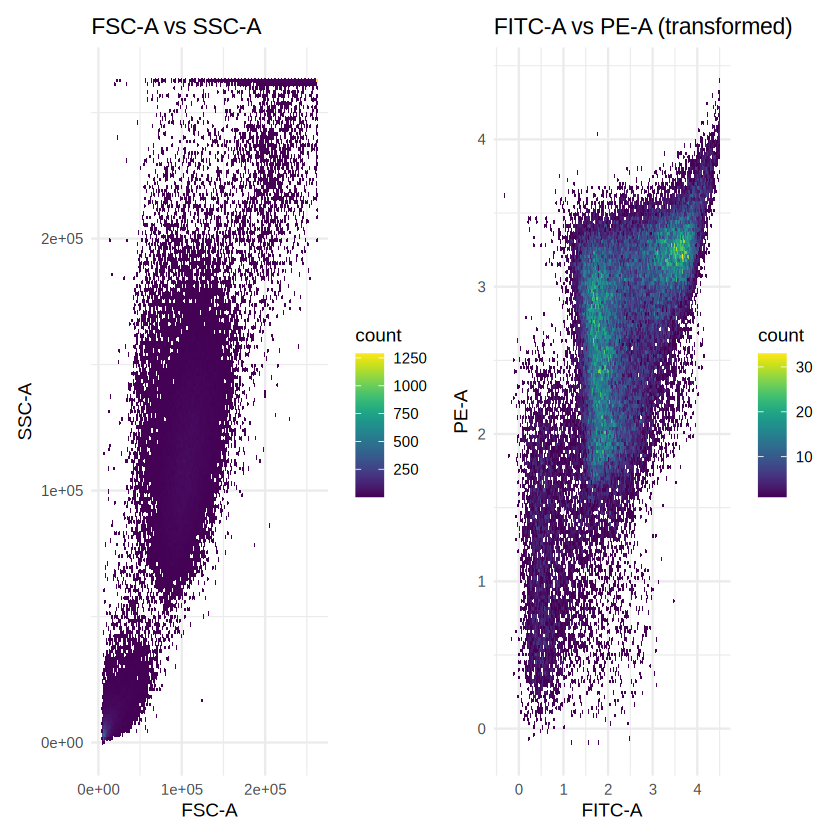

In [8]:
# Pick two fluorescence channels for visualization
if (length(fluor_channels) >= 2) {
    ch1 <- fluor_channels[1]
    ch2 <- fluor_channels[2]
} else {
    ch1 <- fluor_channels[1]
    ch2 <- "SSC-A"
}

# Transformed data as data.frame
df_trans <- as.data.frame(exprs(ff_trans))

p1 <- ggplot(df_trans, aes(x = .data[[ch1]], y = .data[[ch2]])) +
    geom_hex(bins = 150) +
    scale_fill_viridis() +
    theme_minimal() +
    labs(title = paste(ch1, "vs", ch2, "(transformed)"))

p2 <- ggplot(df_trans, aes(x = `FSC-A`, y = `SSC-A`)) +
    geom_hex(bins = 150) +
    scale_fill_viridis() +
    theme_minimal() +
    labs(title = "FSC-A vs SSC-A")

p2 + p1

## 7. Manual gating with flowWorkspace

In [9]:
# Create a GatingSet from the flowFrame
gs <- GatingSet(flowSet(ff_trans))

# Gate 1: Scatter gate (debris removal)
# -- Adjust coordinates to your data --
scatter_gate <- rectangleGate(
    filterId = "nonDebris",
    "FSC-A" = c(50000, 250000),
    "SSC-A" = c(5000, 200000)
)

gs_pop_add(gs, scatter_gate, parent = "root")
recompute(gs)

gs_get_pop_paths(gs)
gs_pop_get_stats(gs)

[1] 2

done!



[1] "root"       "/nonDebris"

sample,pop,count
<chr>,<chr>,<dbl>
V1,root,50000
V1,/nonDebris,34742


In [10]:
# Visualize the scatter gate
ggcyto(gs, aes(x = `FSC-A`, y = `SSC-A`)) +
    geom_hex(bins = 150) +
    geom_gate("nonDebris") +
    geom_stats() +
    scale_fill_viridis() +
    theme_minimal()

ERROR: Error in add_ggcyto(e1, e2, e2name): object '+.gg' not found


## 8. Automated gating with openCyto (optional)

In [11]:
# Example: mindensity gate on a fluorescence channel
# This finds the valley between negative and positive populations
if (length(fluor_channels) >= 1) {
    gs_pop_add(gs, openCyto:::.mindensity,
               parent = "nonDebris",
               dims = fluor_channels[1],
               pop = "+",
               filterId = paste0(fluor_channels[1], "_pos"))
    recompute(gs)
    gs_pop_get_stats(gs)
}

ERROR: Error in gs_pop_add(gs, openCyto:::.mindensity, parent = "nonDebris", : names of gate list do not match with the sample names in the gating set!


## 9. FlowSOM clustering

In [12]:
# Extract gated population
gated_data <- gs_pop_get_data(gs, "nonDebris")[[1]]

# Run FlowSOM on fluorescence channels
fsom <- FlowSOM(
    gated_data,
    colsToUse = fluor_channels,
    nClus = 10,      # meta-clusters
    xdim = 10,
    ydim = 10,
    seed = 42
)

# Get cluster assignments
meta_clusters <- GetMetaclusters(fsom)
cat("Meta-cluster sizes:\n")
table(meta_clusters)

Meta-cluster sizes:


meta_clusters
    1     2     3     4     5     6     7     8     9    10 
10196    96    91  2147  8401   133   958   940  2638  9142 

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
ℹ The deprecated feature was likely used in the FlowSOM package.
  Please report the issue to the authors.”


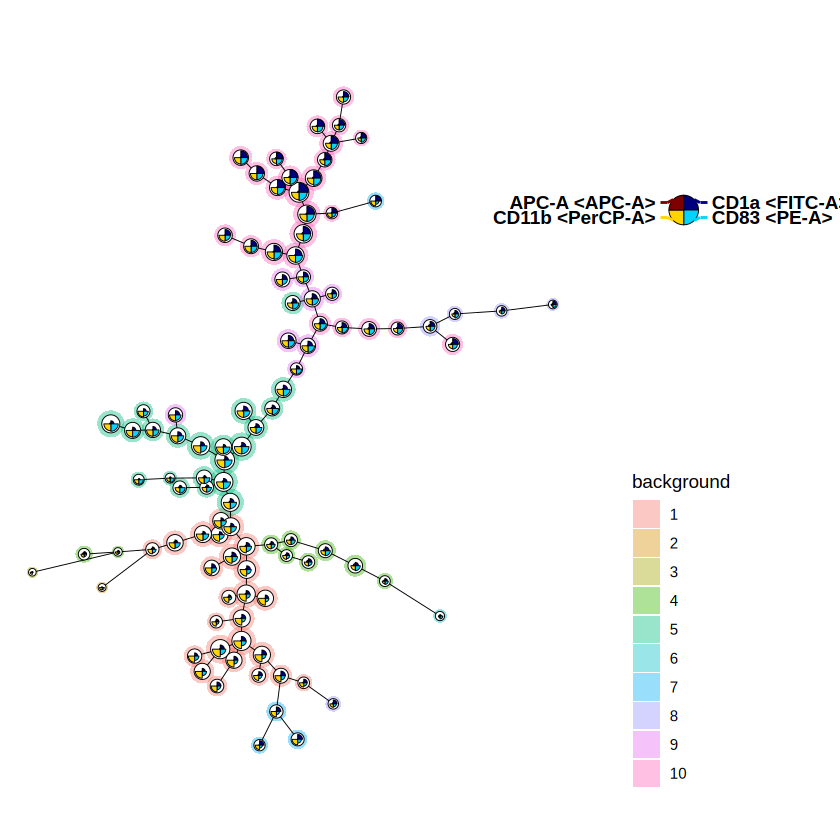

In [13]:
# FlowSOM tree
PlotStars(fsom, backgroundValues = fsom$metaclustering)

## 10. UMAP

In [14]:
mat <- exprs(gated_data)[, fluor_channels]
mat_scaled <- scale(mat)

set.seed(42)
n_sub <- min(nrow(mat_scaled), 10000)
idx <- sample(nrow(mat_scaled), n_sub)

umap_res <- uwot::umap(mat_scaled[idx, ], n_neighbors = 15, min_dist = 0.2)

umap_df <- data.frame(
    UMAP1 = umap_res[, 1],
    UMAP2 = umap_res[, 2],
    cluster = factor(meta_clusters[idx])
)

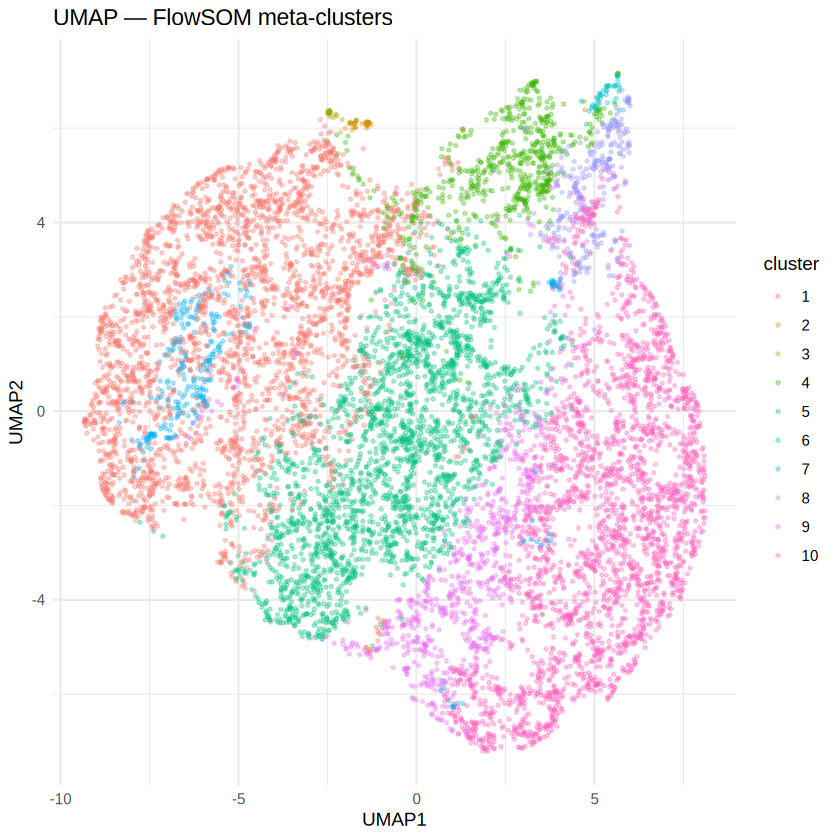

In [15]:
ggplot(umap_df, aes(x = UMAP1, y = UMAP2, color = cluster)) +
    geom_point(alpha = 0.3, size = 0.5) +
    theme_minimal() +
    labs(title = "UMAP — FlowSOM meta-clusters")

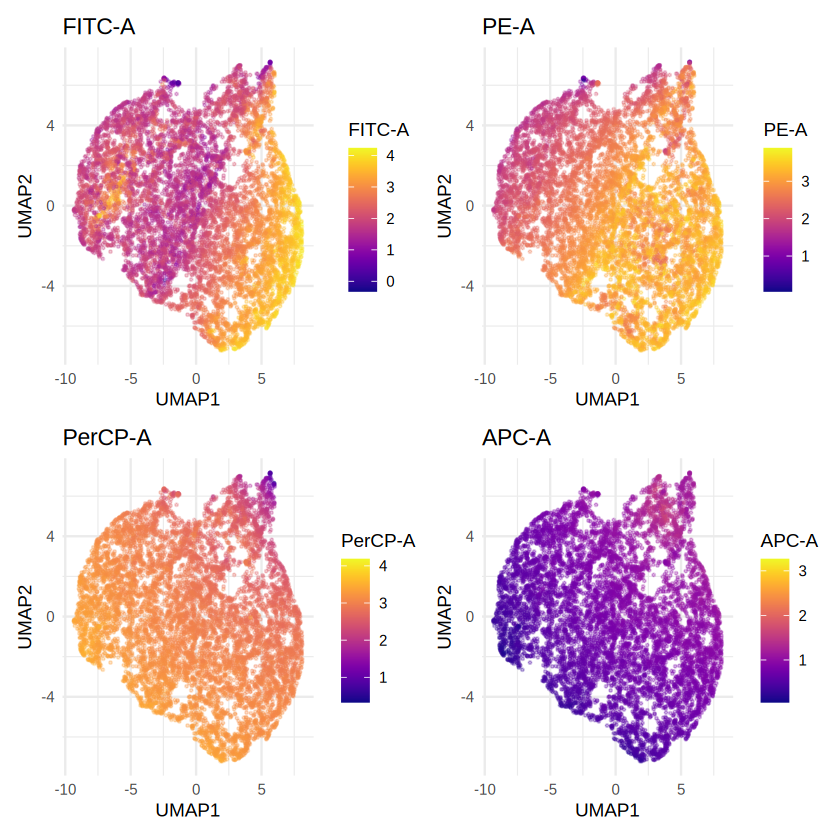

In [16]:
# Color by marker intensity
for (ch in fluor_channels) {
    umap_df[[ch]] <- mat[idx, ch]
}

plots <- lapply(fluor_channels, function(ch) {
    ggplot(umap_df, aes(x = UMAP1, y = UMAP2, color = .data[[ch]])) +
        geom_point(alpha = 0.3, size = 0.3) +
        scale_color_viridis(option = "C") +
        theme_minimal() +
        labs(title = ch)
})

wrap_plots(plots)

## 11. Summary statistics

In [17]:
# Population stats
pop_stats <- gs_pop_get_stats(gs, type = "count")
pop_stats$percent <- pop_stats$count / pop_stats$count[1] * 100
pop_stats

# Cluster MFIs
cluster_mfi <- aggregate(mat[idx, ], by = list(cluster = meta_clusters[idx]), FUN = median)
cluster_mfi

sample,pop,count,percent
<chr>,<chr>,<dbl>,<dbl>
V1,root,50000,100.000
V1,/nonDebris,34742,69.484


cluster,FITC-A,PE-A,PerCP-A,APC-A
<fct>,<dbl>,<dbl>,<dbl>,<dbl>
1,1.8390201,2.2572103,3.105745,0.6822898
2,0.6741665,2.3119853,2.631744,0.9873807
3,0.9849907,0.8882515,2.603274,1.0130526
4,2.0391867,2.5106170,2.576488,1.2675323
5,1.8143876,3.0276123,3.032924,0.7729869
6,1.3939857,2.5512766,1.501398,1.1507549
7,3.0103800,2.1527362,3.178219,0.5988362
8,2.8152603,2.6766757,2.308873,1.1975769
9,2.5809708,3.0672002,3.133203,0.6654940
